<a href="https://colab.research.google.com/github/Gabo190594/recommender-system-supermarket/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis Exploratorio de Datos (EDA)

## 🧾 Descripción del dataset

El presente dataset es **sintético** y simula el comportamiento de usuarios en un e-commerce de supermercado.

Incluye tres tipos de información clave para sistemas de recomendación:

| Archivo | Contenido | Campos |
|--------|----------|--------|
| users.csv | Información de los usuarios | user_id, age, segment |
| products.csv | Información de productos | product_id, category, price |
| interactions.csv | Interacciones de usuarios con productos (comportamiento implícito) | user_id, product_id, event_type (view, cart, purchase), timestamp, implicit_score |
| ratings.csv | Valoraciones de productos por usuarios (preferencias explícitas) | user_id, product_id, rating |
| social_links.csv | Relaciones entre usuarios | user_id, friend_id |


### 👥 Usuarios (`users.csv`)
- user_id: identificador único
- age: edad del usuario
- segment: tipo de cliente (familia, soltero, fitness, gourmet)

### 🛒 Productos (`products.csv`)
- product_id: identificador del producto
- category: categoría del producto
- price: precio

### 🔍 Interacciones (`interactions.csv`) — Datos implícitos
- user_id
- product_id
- event_type: tipo de evento (view, cart, purchase)
- timestamp: fecha de interacción
- implicit_score: peso de la interacción

### ⭐ Ratings (`ratings.csv`) — Datos explícitos
- user_id
- product_id
- rating: valoración de 1 a 5

### 👥 Relaciones sociales (`social_links.csv`)
- user_id
- friend_id

## 🧠 Tipos de datos utilizados

El dataset combina diferentes tipos de señales:

- 🔍 Implícito: interacciones (views, compras, carrito)
- ⭐ Explícito: ratings de usuarios
- 👥 Apoyo social: relaciones entre usuarios
- 📦 Contenido: características de productos

In [37]:
# Clonar tu repositorio desde GitHub
!git clone https://github.com/Gabo190594/recommender-system-supermarket.git

# Entrar a la carpeta del proyecto
%cd recommender-system-supermarket

# Generar data si no existe
import os

if not os.path.exists("data/raw/users.csv"):
    print("Generando data...")
    !python data_generation/generate_data.py
else:
    print("Data ya existe")

Cloning into 'recommender-system-supermarket'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 48 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 135.58 KiB | 3.01 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/recommender-system-supermarket/recommender-system-supermarket/recommender-system-supermarket/recommender-system-supermarket
Data ya existe


In [38]:
import pandas as pd

users = pd.read_csv("data/raw/users.csv")
products = pd.read_csv("data/raw/products.csv")
interactions = pd.read_csv("data/raw/interactions.csv")
ratings = pd.read_csv("data/raw/ratings.csv")
social_links = pd.read_csv("data/raw/social_links.csv")

print("Users:", users.shape)
print("Products:", products.shape)
print("Interactions:", interactions.shape)
print("Ratings:", ratings.shape)

Users: (500, 3)
Products: (800, 3)
Interactions: (15000, 5)
Ratings: (4000, 3)


In [39]:
print(users.head())
print(products.head())
print(interactions.head())
print(ratings.head())

   user_id  age  segment
0        1   56  familia
1        2   46  familia
2        3   32  fitness
3        4   60  fitness
4        5   25  familia
   product_id  category  price
0           1    frutas  94.46
1           2    carnes   4.90
2           3  limpieza  70.85
3           4     hogar  92.60
4           5    carnes  18.88
   user_id  product_id event_type   timestamp  implicit_score
0      320         343       view  2025-05-12               1
1      138         367       view  2025-03-04               1
2       38         465   purchase  2025-05-12               5
3      111         241       view  2025-05-13               1
4      480         199       view  2025-05-18               1
   user_id  product_id  rating
0      219         510       3
1      201          95       4
2      394         414       3
3       27         156       1
4       89         692       2


In [40]:
print(users.isnull().sum())
print(products.isnull().sum())
print(interactions.isnull().sum())
print(ratings.isnull().sum())

user_id    0
age        0
segment    0
dtype: int64
product_id    0
category      0
price         0
dtype: int64
user_id           0
product_id        0
event_type        0
timestamp         0
implicit_score    0
dtype: int64
user_id       0
product_id    0
rating        0
dtype: int64


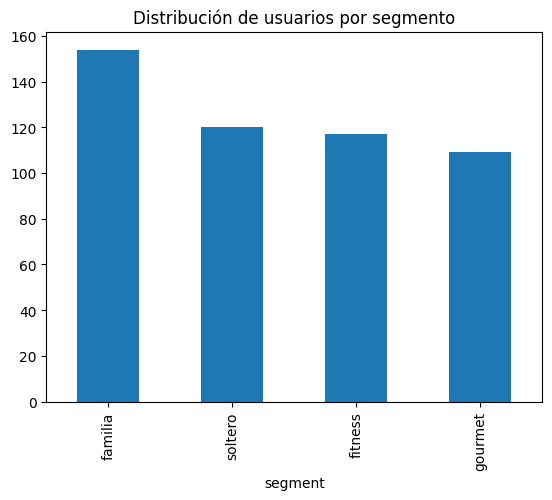

In [41]:
users["segment"].value_counts().plot(kind="bar")
plt.title("Distribución de usuarios por segmento")
plt.show()



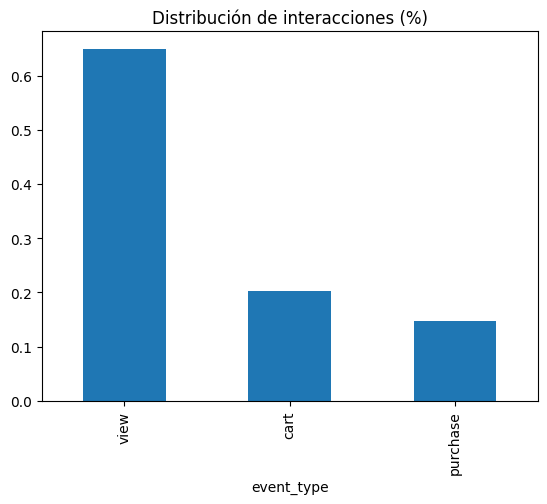

In [42]:
interactions["event_type"].value_counts(normalize=True).plot(kind="bar")
plt.title("Distribución de interacciones (%)")
plt.show()

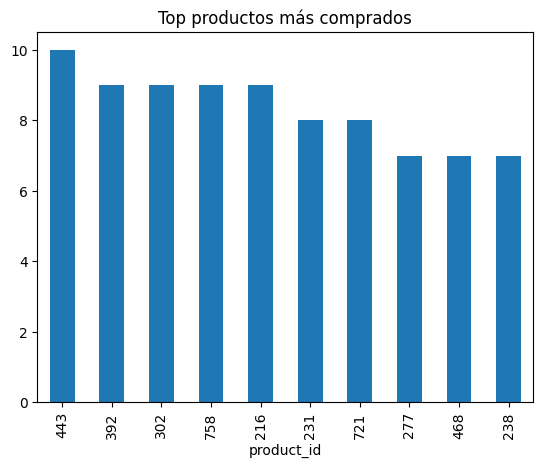

In [43]:
top_products = interactions[interactions["event_type"]=="purchase"]["product_id"].value_counts().head(10)
top_products.plot(kind="bar")
plt.title("Top productos más comprados")
plt.show()

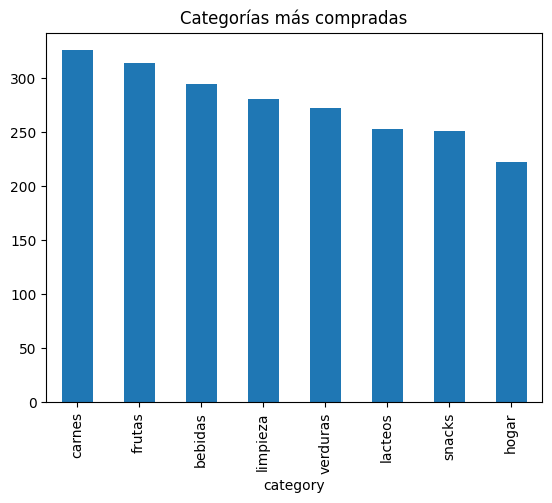

In [44]:
merged = interactions.merge(products, on="product_id")
top_categories = merged[merged["event_type"]=="purchase"]["category"].value_counts()
top_categories.plot(kind="bar")
plt.title("Categorías más compradas")
plt.show()

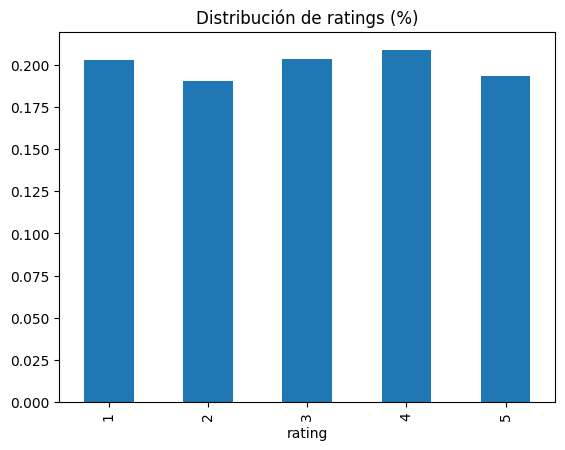

In [45]:
ratings["rating"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Distribución de ratings (%)")
plt.show()

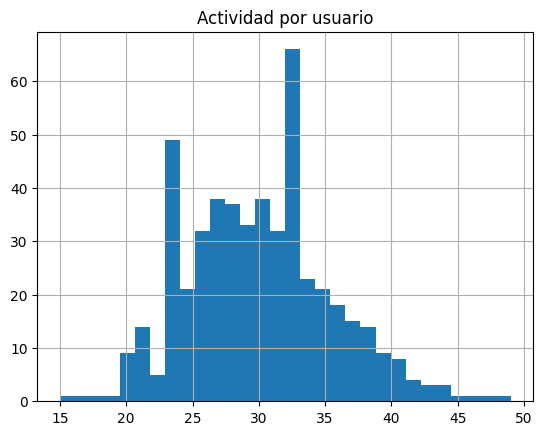

In [46]:
user_activity = interactions["user_id"].value_counts()
user_activity.describe()

user_activity.hist(bins=30)
plt.title("Actividad por usuario")
plt.show()


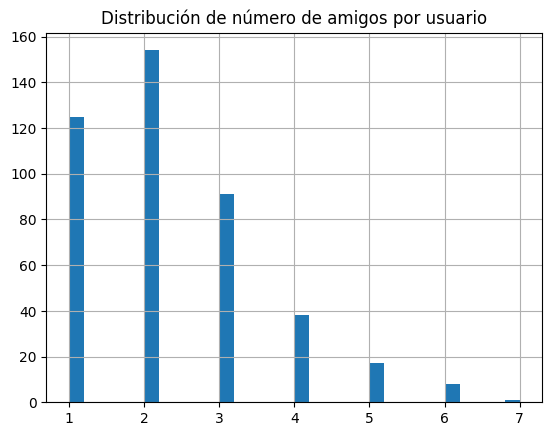

In [47]:
social_links["user_id"].value_counts().head(10)
social_links["user_id"].value_counts().hist(bins=30)
plt.title("Distribución de número de amigos por usuario")
plt.show()

In [48]:
merged = interactions.merge(products, on="product_id")
merged.groupby("category")["implicit_score"].mean().sort_values(ascending=False)

,implicit_score
category,
carnes,2.030534
bebidas,2.015354
snacks,2.011439
frutas,2.006369
lacteos,1.990940
verduras,1.986211
limpieza,1.976959
hogar,1.952150


In [49]:
interaction_matrix = interactions.pivot_table(
    index="user_id",
    columns="product_id",
    values="implicit_score",
    aggfunc="sum"
)

import numpy as np

num_total = interaction_matrix.shape[0] * interaction_matrix.shape[1]
num_observed = np.count_nonzero(~interaction_matrix.isna())

sparsity = 1 - (num_observed / num_total)

print("Sparsity:", sparsity)

Sparsity: 0.9644625


In [58]:
from IPython.display import Markdown, display
import numpy as np

# =========================
# MÉTRICAS
# =========================

user_activity = interactions.groupby("user_id").size()
avg_activity = user_activity.mean()

avg_rating = ratings["rating"].mean()

merged = interactions.merge(products, on="product_id")
top_category = merged["category"].value_counts().idxmax()

# Sparsity
interaction_matrix = interactions.pivot_table(
    index="user_id",
    columns="product_id",
    values="implicit_score",
    aggfunc="sum"
)

num_total = interaction_matrix.shape[0] * interaction_matrix.shape[1]
num_observed = np.count_nonzero(~interaction_matrix.isna())
sparsity = 1 - (num_observed / num_total)

# =========================
# INTERPRETACIÓN DINÁMICA
# =========================

# Actividad
if avg_activity < 10:
    activity_text = "baja, lo que indica poca información por usuario"
elif avg_activity < 30:
    activity_text = "moderada, permitiendo entender parcialmente las preferencias"
else:
    activity_text = "alta, lo que permite identificar claramente patrones de comportamiento"

# Rating
if avg_rating < 2.5:
    rating_text = "bajas, lo que indica insatisfacción general"
elif avg_rating < 3.5:
    rating_text = "neutrales, lo que sugiere ausencia de preferencias marcadas"
else:
    rating_text = "altas, lo que indica satisfacción general"

# Sparsity
if sparsity > 0.9:
    sparsity_text = "alta, lo que indica que la mayoría de combinaciones usuario-producto no tienen interacción"
else:
    sparsity_text = "moderada, con suficiente información en la matriz"

# =========================
# OUTPUT MARKDOWN
# =========================

markdown_text = f"""
## 📌 Interpretación de resultados

- 👤 La actividad promedio por usuario es de **{avg_activity:.2f} interacciones**
  → Esto indica una actividad {activity_text}.

- ⭐ El rating promedio es **{avg_rating:.2f}**
  → Las valoraciones son {rating_text}.

- 📦 La categoría con mayor interacción es **{top_category}**, lo que indica mayor interés de los usuarios en este tipo de productos.

- ⚠️ La sparsity de la matriz usuario-producto es **{sparsity:.2f}**
  → Esto indica una dispersión {sparsity_text}.
"""

display(Markdown(markdown_text))


## 📌 Interpretación de resultados

- 👤 La actividad promedio por usuario es de **30.00 interacciones**  
  → Esto indica una actividad alta, lo que permite identificar claramente patrones de comportamiento.

- ⭐ El rating promedio es **3.00**  
  → Las valoraciones son neutrales, lo que sugiere ausencia de preferencias marcadas.

- 📦 La categoría con mayor interacción es **carnes**, lo que indica mayor interés de los usuarios en este tipo de productos.

- ⚠️ La sparsity de la matriz usuario-producto es **0.96**  
  → Esto indica una dispersión alta, lo que indica que la mayoría de combinaciones usuario-producto no tienen interacción.
